In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [2]:
df = pd.read_csv("../data/energy_data.csv")
df.columns = df.columns.str.strip()
df[df.columns[0]] = pd.to_datetime(df[df.columns[0]])
df.set_index(df.columns[0], inplace=True)
df.head()

,fridge,ac,lights,microwave,total_power
timestamp,,,,,
2023-01-01 00:00:00,119,0,73,0,192
2023-01-01 01:00:00,134,0,0,0,134
2023-01-01 02:00:00,0,1551,73,0,1624
2023-01-01 03:00:00,0,0,66,0,66
2023-01-01 04:00:00,83,0,86,0,169


In [7]:
import pandas as pd

df.index = pd.to_datetime(df.index)
hourly = df['total_power'].resample('H').mean()

hourly.head()

C:\Users\DELL\AppData\Local\Temp\ipykernel_19704\841498673.py:4: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  hourly = df['total_power'].resample('H').mean()


timestamp
2023-01-01 00:00:00     192.0
2023-01-01 01:00:00     134.0
2023-01-01 02:00:00    1624.0
2023-01-01 03:00:00      66.0
2023-01-01 04:00:00     169.0
Freq: h, Name: total_power, dtype: float64

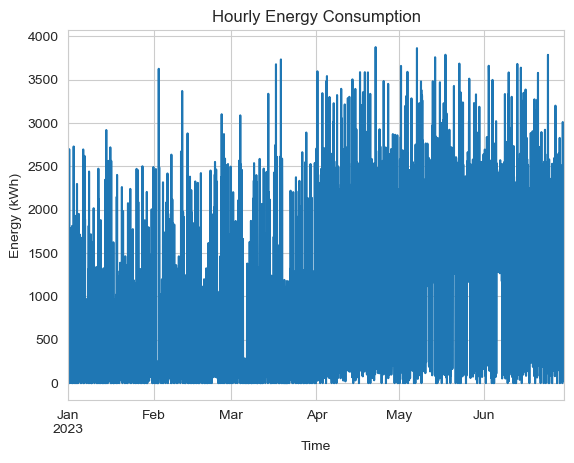

In [8]:
hourly.plot()
plt.title("Hourly Energy Consumption")
plt.xlabel("Time")
plt.ylabel("Energy (kWh)")
plt.show()

In [9]:
peak_hour = hourly.idxmax()
print("Peak Consumption Hour:", peak_hour)
print("Peak Value:", hourly.max())

Peak Consumption Hour: 2023-04-22 13:00:00
Peak Value: 3875.0


In [10]:
df['hour'] = df.index.hour
df.head()

,fridge,ac,lights,microwave,total_power,hour
timestamp,,,,,,
2023-01-01 00:00:00,119,0,73,0,192,0
2023-01-01 01:00:00,134,0,0,0,134,1
2023-01-01 02:00:00,0,1551,73,0,1624,2
2023-01-01 03:00:00,0,0,66,0,66,3
2023-01-01 04:00:00,83,0,86,0,169,4


In [12]:

df.index = pd.to_datetime(df.index)

df['hour'] = df.index.hour

hour_pattern = df.groupby('hour')['total_power'].mean()

hour_pattern

hour
0     1084.535912
1     1035.644444
2      976.594444
3     1023.305556
4     1096.922222
5     1005.255556
6     1106.494444
7      992.133333
8      960.405556
9      941.116667
10     991.622222
11    1019.977778
12     999.733333
13    1039.738889
14     911.516667
15    1012.672222
16    1021.233333
17     948.122222
18    1065.822222
19    1024.777778
20     942.816667
21    1026.761111
22    1025.055556
23    1114.655556
Name: total_power, dtype: float64

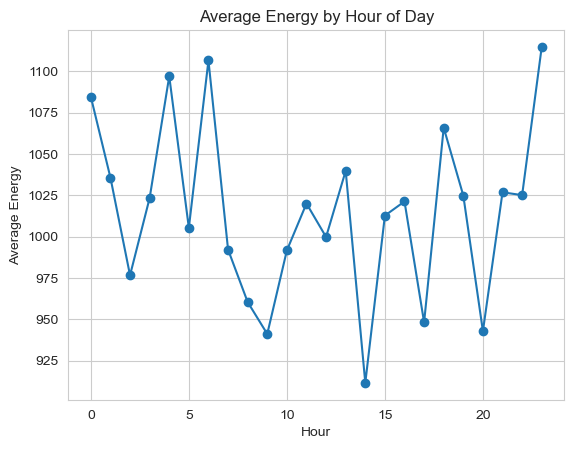

In [13]:
hour_pattern.plot(marker='o')
plt.title("Average Energy by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Average Energy")
plt.show()

In [15]:
print("Hourly Mean:", hourly.mean())
print("Hourly Standard Deviation:", hourly.std())

Hourly Mean: 1015.3040962740106
Hourly Standard Deviation: 975.3953866416575
